# 02 Baseline Model Training & Evaluation

This notebook establishes the **Unimodal Baseline** (CNN-only for images, biLSTM-only for text) as defined in the Project Intended comparison table.

## 1. Environment & Global Setup

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import platform
import torch
from pathlib import Path

def setup_environment():
    print("--- MediSim Environment Setup ---")
    is_colab = "COLAB_GPU" in os.environ
    if is_colab:
        from google.colab import drive
        drive.mount('/content/drive')
        # Set working directory to the notebooks folder in Drive
        project_path = '/content/drive/My Drive/AIT/NLP/NLP_Project/MediSim/notebooks'
        if os.path.exists(project_path):
            os.chdir(project_path)
            print(f"Colab: Connected and switched to {os.getcwd()}")
        else:
            print(f"WARNING: Project path not found: {project_path}")

    device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    return device

device = setup_environment()

--- MediSim Environment Setup ---
Device: mps


## 2. Dataset & Architecture Preparation

In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import numpy as np

class UnimodalDataset(Dataset):
    def __init__(self, csv_file, img_dir, mode='image', transform=None, vocab=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mode = mode
        self.transform = transform
        self.vocab = vocab
        self.label_encoder = LabelEncoder()
        self.df['label_idx'] = self.label_encoder.fit_transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        label = torch.tensor(self.df.iloc[idx]['label_idx'])
        if self.mode == 'image':
            img_path = os.path.join(self.img_dir, self.df.iloc[idx]['filename'])
            image = Image.open(img_path).convert('RGB')
            if self.transform: image = self.transform(image)
            return image, label
        else:
            text = str(self.df.iloc[idx]['findings'])
            tokens = [self.vocab.get(w, 0) for w in text.split()][:50]
            tokens = tokens + [0] * (50 - len(tokens))
            return torch.tensor(tokens, dtype=torch.long), label

# Baseline Architectures
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        self.resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.resnet.fc = nn.Linear(512, num_classes)
    def forward(self, img):
        return self.resnet(img)

class BaselineLSTM(nn.Module):
    def __init__(self, vocab_size, num_classes=15):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128)
        self.lstm = nn.LSTM(128, 256, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, num_classes)
    def forward(self, text):
        embedded = self.embedding(text)
        _, (hn, _) = self.lstm(embedded)
        feat = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(feat)

print("Baseline Architectures & Dataset Class Ready")

Baseline Architectures & Dataset Class Ready


## 3. Evaluation Function & Benchmark
As requested, we implement robust metrics (Accuracy, Precision, Recall, F1) to verify model performance.

In [3]:
def evaluate_model(model, loader, device, is_multimodal=False):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            if is_multimodal:
                imgs, texts, labels = data
                imgs, texts = imgs.to(device), texts.to(device)
                outputs = model(imgs, texts)
            else:
                inputs, labels = data[0].to(device), data[-1]
                outputs = model(inputs)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n--- Evaluation Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("--------------------------")
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

def save_model(model, filename):
    save_path = f"../data/{filename}"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to: {save_path}")

def train_baseline_cnn(model, train_loader, val_loader, device, epochs=5, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_f1 = -1.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / max(len(train_loader), 1)
        val_metrics = evaluate_model(model, val_loader, device)
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best validation F1: {best_val_f1:.4f}")
    return model

print("Evaluation, Training, and Saving Functions Ready")

Evaluation, Training, and Saving Functions Ready


## 4. Example Usage: Unimodal CNN Baseline
Ensure you have run `01_data_pipeline.ipynb` first to generate `../data/processed_metadata.csv`.

In [4]:
# Paths
METADATA_PATH = "../data/processed_metadata.csv"
IMAGES_DIR = "../data/images/images_normalized"
MODEL_PATH = "../data/baseline_cnn.pth"

# Toggle this if you want to force retraining even when a checkpoint exists.
TRAIN_FROM_SCRATCH = True
EPOCHS = 5
BATCH_SIZE = 32

if os.path.exists(METADATA_PATH):
    import random
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset = UnimodalDataset(METADATA_PATH, IMAGES_DIR, mode='image', transform=transform)

    n_total = len(dataset)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    split_generator = torch.Generator().manual_seed(SEED)
    train_set, val_set, test_set = random_split(
        dataset, [n_train, n_val, n_test], generator=split_generator
    )

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

    num_classes = len(dataset.label_encoder.classes_)
    model = BaselineCNN(num_classes=num_classes).to(device)

    if os.path.exists(MODEL_PATH) and not TRAIN_FROM_SCRATCH:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f"Loaded checkpoint without retraining: {MODEL_PATH}")
    else:
        print("Training baseline CNN...")
        model = train_baseline_cnn(
            model, train_loader, val_loader, device, epochs=EPOCHS, lr=1e-4
        )
        save_model(model, "baseline_cnn.pth")

    print(f"Running test evaluation on {len(test_set)} images...")
    test_metrics = evaluate_model(model, test_loader, device)
    print(f"Final test metrics: {test_metrics}")

    # Keep these names for downstream visualization cell compatibility.
    loader = test_loader
else:
    print("Metadata file not found! Please run the Data Pipeline notebook first.")

Training baseline CNN...

--- Evaluation Results ---
Accuracy:  0.5157
Precision: 0.4373
Recall:    0.5157
F1 Score:  0.4070
--------------------------
Epoch 1/5 | Train Loss: 1.9043 | Val F1: 0.4070

--- Evaluation Results ---
Accuracy:  0.5108
Precision: 0.4529
Recall:    0.5108
F1 Score:  0.4559
--------------------------
Epoch 2/5 | Train Loss: 1.1121 | Val F1: 0.4559

--- Evaluation Results ---
Accuracy:  0.5205
Precision: 0.4667
Recall:    0.5205
F1 Score:  0.4890
--------------------------
Epoch 3/5 | Train Loss: 0.5149 | Val F1: 0.4890

--- Evaluation Results ---
Accuracy:  0.5133
Precision: 0.4532
Recall:    0.5133
F1 Score:  0.4688
--------------------------
Epoch 4/5 | Train Loss: 0.1686 | Val F1: 0.4688

--- Evaluation Results ---
Accuracy:  0.5349
Precision: 0.4660
Recall:    0.5349
F1 Score:  0.4856
--------------------------
Epoch 5/5 | Train Loss: 0.0597 | Val F1: 0.4856
Best validation F1: 0.4890
Model saved to: ../data/baseline_cnn.pth
Running test evaluation on 417 i

## 5. Visualization: Baseline Evaluation Insights
This section visualizes confusion matrix, class support, and confidence distribution, then exports chart-ready metrics for the web dashboard.

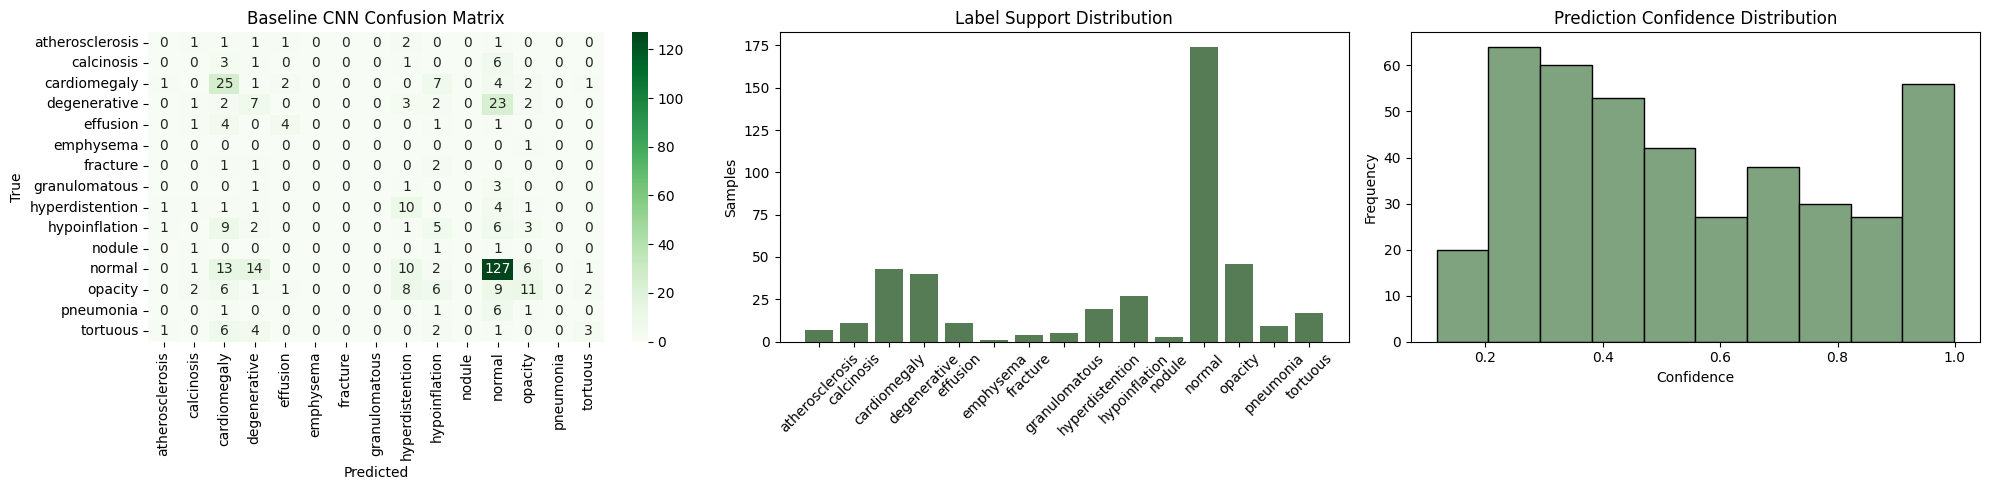

Baseline insights exported to: ../data/model_insights.json
Web dashboard data updated at: ../web_app_pro/frontend/public/model_insights.json


In [5]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

if 'model' in globals() and 'loader' in globals() and 'dataset' in globals():
    model.eval()
    all_preds, all_labels, all_conf = [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
            all_conf.extend(np.max(probs, axis=1).tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    class_names = dataset.label_encoder.classes_.tolist()
    cm = confusion_matrix(all_labels, all_preds)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title('Baseline CNN Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    support = np.bincount(np.array(all_labels), minlength=len(class_names))
    axes[1].bar(class_names, support, color='#557c55')
    axes[1].set_title('Label Support Distribution')
    axes[1].set_ylabel('Samples')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].hist(all_conf, bins=10, color='#7fa27f', edgecolor='black')
    axes[2].set_title('Prediction Confidence Distribution')
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    counts, bin_edges = np.histogram(all_conf, bins=10, range=(0.0, 1.0))
    baseline_metrics = {
        'summary': {
            'accuracy': float(acc),
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1),
            'samples': int(len(all_labels))
        },
        'class_names': class_names,
        'confusion_matrix': cm.tolist(),
        'class_support': support.tolist(),
        'confidence_histogram': {
            'bin_edges': bin_edges.tolist(),
            'counts': counts.tolist()
        }
    }

    insights_path = Path('../data/model_insights.json')
    insights_path.parent.mkdir(parents=True, exist_ok=True)
    if insights_path.exists():
        with open(insights_path, 'r') as f:
            insights = json.load(f)
    else:
        insights = {}

    insights['baseline'] = baseline_metrics

    with open(insights_path, 'w') as f:
        json.dump(insights, f, indent=2)

    web_path = Path('../web_app_pro/frontend/public/model_insights.json')
    web_path.parent.mkdir(parents=True, exist_ok=True)
    with open(web_path, 'w') as f:
        json.dump(insights, f, indent=2)

    print(f'Baseline insights exported to: {insights_path}')
    print(f'Web dashboard data updated at: {web_path}')
else:
    print('Please run the training/evaluation cells first so model, loader, and dataset are available.')